In [1]:
import pandas as pd 
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform
import joblib 

In [5]:
df = pd.read_parquet(r"Data\featured_data.parquet")

FileNotFoundError: [Errno 2] No such file or directory: 'Data\\featured_data.parquet'

In [ ]:
df.head() 

,id,date,store_nbr,item_nbr,unit_sales,onpromotion,family,class,perishable,city,...,oil_mean_14,oil_std_14,oil_max_14,oil_min_14,oil_median_14,oil_mean_30,oil_std_30,oil_max_30,oil_min_30,oil_median_30
0,690,2013-01-02,1,211999,2.0,False,GROCERY I,1036,0,Quito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,42354,2013-01-03,1,211999,1.0,False,GROCERY I,1036,0,Quito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,122511,2013-01-05,1,211999,2.0,False,GROCERY I,1036,0,Quito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,206904,2013-01-07,1,211999,1.0,False,GROCERY I,1036,0,Quito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,285342,2013-01-09,1,211999,3.0,False,GROCERY I,1036,0,Quito,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum()

id                0
date              0
store_nbr         0
item_nbr          0
unit_sales        0
                 ..
oil_mean_30      30
oil_std_30       30
oil_max_30       30
oil_min_30       30
oil_median_30    30
Length: 65, dtype: int64

In [ ]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

print(missing[missing > 0])

rolling_median_30    43685
rolling_std_30       43685
rolling_min_30       43685
rolling_max_30       43685
rolling_mean_30      43685
lag_28               40840
rolling_std_14       20643
lag_14               20643
rolling_mean_14      20643
rolling_median_14    20643
rolling_min_14       20643
rolling_max_14       20643
rolling_max_7        10383
rolling_min_7        10383
lag_7                10383
rolling_median_7     10383
rolling_mean_7       10383
rolling_std_7        10383
lag_1                 1500
oil_median_30           30
oil_mean_30             30
oil_max_30              30
oil_min_30              30
oil_std_30              30
oil_std_14              14
oil_min_14              14
oil_median_14           14
oil_mean_14             14
oil_max_14              14
oil_median_7             7
oil_std_7                7
oil_min_7                7
oil_max_7                7
oil_mean_7               7
oil_two_days_diff        2
dtype: int64


In [ ]:
df_sorted = df.sort_values('date').reset_index(drop=True)

In [ ]:
drop_cols = [
    'unit_sales',
    'id',
    'date',
    'transactions', 
    'description'   
]

x = df.drop(columns=drop_cols)
y = df["unit_sales"]

In [ ]:
split_index = int(len(x)*0.8)
x_train = x.iloc[:split_index]
x_test = x.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [ ]:
cat_cols = [
    'store_nbr', 'item_nbr', 'family', 'class',
    'city', 'state', 'store_type',
    'holiday_type', 'locale', 'locale_name'
]
num_cols = x.drop(columns=cat_cols).columns

In [ ]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant",fill_value=0)),
    ("scaler",StandardScaler())
]
)

cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown="ignore",))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe,num_cols),
    ("cat",cat_pipe,cat_cols)
])

In [ ]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [ ]:
y_series = pd.Series(y_train)
y_series.describe()

count    870841.000000
mean          7.279945
std          18.822769
min         -94.000000
25%           2.000000
50%           4.000000
75%           8.000000
max       10000.000000
Name: unit_sales, dtype: float64

In [ ]:
y_series = pd.Series(y_train)

for q in [0.90, 0.95, 0.99, 0.995, 0.999, 0.9999]:
    print(f"{q*100:.2f}th percentile: {y_series.quantile(q):.2f}")

print()
print("Count > 100:", (y_series > 100).sum())
print("Count > 500:", (y_series > 500).sum())
print("Count > 1000:", (y_series > 1000).sum())
print("Count > 5000:", (y_series > 5000).sum())

90.00th percentile: 16.00
95.00th percentile: 24.00
99.00th percentile: 53.00
99.50th percentile: 79.00
99.90th percentile: 160.82
99.99th percentile: 409.00

Count > 100: 2913
Count > 500: 59
Count > 1000: 21
Count > 5000: 1


In [ ]:

upper_clip = y_series.quantile(0.999)
lower_clip = y_series.quantile(0.001)
y_train = np.clip(y_train,lower_clip, upper_clip)

In [ ]:
def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

def signed_inverse_log(x):
    return np.sign(x) * np.expm1(np.abs(x))

y_train_t = signed_log(y_train)
y_test_t =  signed_log(y_test)

In [ ]:
tscv=TimeSeriesSplit(n_splits=5)
lgb_model = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_estimators=5000
)
param = {
    "learning_rate": uniform(0.01, 0.09),
    "num_leaves": randint(31, 128),
    "max_depth": randint(6, 12),
    "min_child_samples": randint(20, 100),
    "subsample": uniform(0.8, 0.2),
    "colsample_bytree": uniform(0.8, 0.2),
    "reg_alpha": uniform(0, 2),
    "reg_lambda": uniform(0, 2),
    "min_split_gain": uniform(0, 0.05)
}

random_search = RandomizedSearchCV(
    estimator = lgb_model,
    param_distributions=param,
    n_iter=3,
    cv=tscv,
    verbose=2,
    random_state = 42,
    n_jobs=-1,
    scoring = "neg_root_mean_squared_error"
)

random_search.fit(
    x_train,
    y_train_t,
    eval_set = [(x_test, y_test_t)],
    eval_metric = "rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False)
    ]
)

print("Best RMSE:", -random_search.best_score_)
print("Best Parameters:",random_search.best_params_)


Fitting 5 folds for each of 3 candidates, totalling 15 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.159117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10081
[LightGBM] [Info] Number of data points in the train set: 145141, number of used features: 363
[LightGBM] [Info] Start training from score 1.667217
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.362036 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10522
[LightGBM] [Info] Number of data points in the train set: 290281, number of used features: 599
[LightGBM] [Info] Start training from score 1.690546
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.620347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 10941
[LightGBM] [Info] Number of data points in the train set: 435421, number of used features: 816
[LightGBM] [Info] Start training from score 1.675054
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.617182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12046
[LightGBM] [Info] Number of data points in the train set: 870841, number of used features: 1367
[LightGBM] [Info] Start training from score 1.673027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [ ]:
best_model = random_search.best_estimator_

In [ ]:
y_pred_t = best_model.predict(x_test)
y_pred = signed_inverse_log(y_pred_t)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

RMSE: 18.3172
MAE:  4.6935
R²:   0.4586


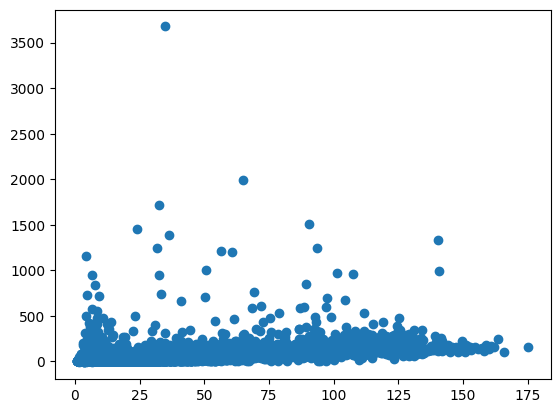

In [ ]:
plt.scatter(y_pred, y_test)

In [ ]:
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

['model.pkl']

In [ ]:
joblib.dump(full_pipeline, "Forecaster.pkl")